# Import

In [1]:
import os
import h5py as h5
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# ------------------------------
# Plot style
# ------------------------------
matplotlib.rcParams.update({
    'font.size': 20,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.major.size': 6,
    'ytick.minor.size': 3,
    'xtick.major.width': 1,
    'ytick.major.width': 1,
    'xtick.minor.width': 0.8,
    'ytick.minor.width': 0.8,
    'xtick.top': True,
    'ytick.right': True,
    'xtick.bottom': True,
    'ytick.left': True,
    
    'text.usetex': True,  # Enable LaTeX rendering
    'font.family': 'serif',
    'font.serif': ['Computer Modern'],  # LaTeX default font
})


## Load COMPAS

In [2]:
Zsun      = 0.02
threshold = 1.00  # MRR condition: m2_BH > threshold * m1_BH (birth ordering)

with h5.File("processed_yields_COMPAS.h5", "r") as f:
    z_vals_compas    = f["z_values"][()]
    Y_compas         = f["yields"][()]
    mass_1           = f["event_properties/mass_1"][()]
    mass_2           = f["event_properties/mass_2"][()]
    zams_1           = f["event_properties/zams_mass_1"][()]
    zams_2           = f["event_properties/zams_mass_2"][()]
    metallicity      = f["event_properties/metallicity"][()]
    formation_weight = f["event_properties/Weight"][()] / 77708655  # per solar mass
    z_vals           = f["z_values"][()]
    Y                = f["yields"][()]

# MRR flag: star 2 (initially less massive) forms the heavier BH
MRR_mask = mass_2 > mass_1
logZ     = np.log10(metallicity / Zsun)

# Load COMPAS raw DCO data for channel classification
compas_path = "../sims/fiducial_compas/fiducial/COMPASCompactOutput_BBH_A.h5"
with h5.File(compas_path, "r") as f:
    dco      = f["doubleCompactObjects"]
    he1_raw  = dco["HeCoreMassDCOFormation1"][()].squeeze()
    he2_raw  = dco["HeCoreMassDCOFormation2"][()].squeeze()
    ppisn1_raw = dco["PPISNPrimary"][()].squeeze()
    ppisn2_raw = dco["PPISNSecondary"][()].squeeze()

## Load SEVN

In [4]:
with h5.File("../data/yields/sevn_updated.hdf5", "r") as f:
    z_vals_sevn = f["z_values"][()]
    Y_sevn      = f["yields"][()]

# Load SEVN simulation output (raw binary properties)
df_SEVN = pd.read_hdf("../sims/master_bbh.h5", key="bbh")

df_SEVN = df_SEVN.rename(columns={
    "ZAMS_M0":    "zams_mass_1",
    "ZAMS_M1":    "zams_mass_2",
    "Massrem_0":  "mass_1",
    "Massrem_1":  "mass_2",
    "Metallicity":"metallicity",
    "ZAMS_ecc":   "eccentricity",
})


df_SEVN["delay_time_in_years"] = df_SEVN["MergerTime"] * 1e6
df_SEVN["MRR"]   = df_SEVN["mass_2"] > df_SEVN["mass_1"]
df_SEVN["qzams"] = df_SEVN["zams_mass_2"] / df_SEVN["zams_mass_1"]
df_SEVN["logZ"]  = np.log10(df_SEVN["metallicity"] / Zsun)

For the formation efficiency we can calculate it real quick

In [5]:
def analytical_star_forming_mass_per_binary_using_kroupa_imf(
        m1_min, m1_max, m2_min, fbin=1., imf_mass_bounds=[0.01,0.08,0.5,200]
):
    """
    Analytical computation of the mass of stars formed per binary star formed within the
    [m1 min, m1 max] and [m2 min, ..] rage,
    using the Kroupa IMF:

        p(M) \propto M^-0.3 for M between m1 and m2
        p(M) \propto M^-1.3 for M between m2 and m3;
        p(M) = alpha * M^-2.3 for M between m3 and m4;

    @Ilya Mandel's derivation
    """
    m1, m2, m3, m4 = imf_mass_bounds
    if m1_min < m3:
        raise ValueError(f"This analytical derivation requires IMF break m3  < m1_min ({m3} !< {m1_min})")
    alpha = (-(m4**(-1.3)-m3**(-1.3))/1.3 - (m3**(-0.3)-m2**(-0.3))/(m3*0.3) + (m2**0.7-m1**0.7)/(m2*m3*0.7))**(-1) # normalization //Tyler
    # average mass of stars (average mass of all binaries is a factor of 1.5 larger)
    m_avg = alpha * (-(m4**(-0.3)-m3**(-0.3))/0.3 + (m3**0.7-m2**0.7)/(m3*0.7) + (m2**1.7-m1**1.7)/(m2*m3*1.7))
    # fraction of binaries that COMPAS simulates
    fint = -alpha / 1.3 * (m1_max ** (-1.3) - m1_min ** (-1.3)) + alpha * m2_min / 2.3 * (m1_max ** (-2.3) - m1_min ** (-2.3))
    # mass represented by each binary simulated by COMPAS
    m_rep = (1/fint) * m_avg * (1.5 + (1-fbin)/fbin)
    return m_rep

# Below, we caluclate for each binary, so at one Z and one M1 how many binaries did I simulate, this would equate to per event

N_Z = 20 ; N_M1 = 197; N_M2 = 100; N_P = 100; N_e =20; 
n_sim_per_binary = N_M1*N_M2*N_P*N_e
print(f"Ntotal systems simulated: {n_sim_per_binary:.2e}")

starform_SEVN =analytical_star_forming_mass_per_binary_using_kroupa_imf(3,200,0,1) 
print(starform_SEVN)

# IMF weight
alpha = -2.3
m_min, m_max = 3, 200
norm = (m_max**(alpha + 1) - m_min**(alpha + 1)) / (alpha + 1)
df_SEVN["Weight_norm"] = 197 * (df_SEVN["zams_mass_1"] ** alpha) / norm # adaptive sampling, need 197



df_SEVN["number_per_solar_mass_values"] = df_SEVN["Weight_norm"]/(starform_SEVN*n_sim_per_binary)



Ntotal systems simulated: 3.94e+07
39.94249161845381


In [6]:
# ── SEVN channel classification ───────────────────────────────────────────────
# Priority: core growth (He core grew past primary's) > PPISN shrink > other
PPISN_TYPE = 3
PISN_TYPE  = 4

def classify_sevn(row):
    if not np.isfinite(row["MHe0_preSN"]) or not np.isfinite(row["MHe1_preSN"]):
        return "nan_MHe"
    if row["MHe1_preSN"] > row["MHe0_preSN"]:
        return "core_growth"
    if row["sn_type_0"] in (PPISN_TYPE, PISN_TYPE) or row["sn_type_1"] in (PPISN_TYPE, PISN_TYPE):
        return "ppisn_shrink"
    return "other"

df_SEVN["channel"] = df_SEVN.apply(classify_sevn, axis=1)

df_mrr_sevn = df_SEVN[df_SEVN["MRR"]].copy()
print("\nSEVN MRR channel breakdown:")
print(df_mrr_sevn["channel"].value_counts())
print(df_mrr_sevn["channel"].value_counts(normalize=True).mul(100).round(1).astype(str) + "%")


SEVN MRR channel breakdown:
channel
core_growth     2258388
ppisn_shrink    1285966
other             44437
Name: count, dtype: int64
channel
core_growth     62.9%
ppisn_shrink    35.8%
other            1.2%
Name: proportion, dtype: object


In [7]:
# SEVN channels
outcomes_sevn = {
    "ppisn_shrink": "PPISN Shrinking",
    "core_growth":  "Core Growth",
    "other":        "Asymmetric CCSN",
}
colors_sevn = {
    "ppisn_shrink": "green",
    "core_growth":  "magenta",
    "other":        "cornflowerblue",
}

# COMPAS channels 
outcomes_compas = {
    "core_growth":    "Core Growth",
    "ppisn_assisted": "PPISN-Assisted",
}
colors_compas = {
    "core_growth":    "deeppink",
    "ppisn_assisted": "forestgreen",
}


# Metallicity bin edges differ between codes due to grid coverage
Z_edges_sevn   = np.linspace(-4.5, 0.0, 20)
Z_edges_compas = np.linspace(-2.5, 0.0, 20)

# Redshift slice index (z ~ 0.2) used for yield weights
z_idx = 2


In [8]:
# ── SEVN: attach yield weights and filter to MRR systems ─────────────────────
assert len(Y_sevn[z_idx]) == len(df_SEVN), "Yield array must align row-for-row with df_SEVN."
df_SEVN["yield_w"] = np.asarray(Y_sevn[z_idx])

df_mrr_sevn = df_SEVN[df_SEVN["MRR"]].copy()

print("SEVN MRR channel breakdown:")
print(df_mrr_sevn["channel"].value_counts())
print(df_mrr_sevn["channel"].value_counts(normalize=True).mul(100).round(1).astype(str) + "%")

# ── COMPAS: classify MRR systems and attach both weight columns ───────────────
# Core growth:    secondary He core exceeds primary's at DCO formation
# PPISN-assisted: primary or secondary flagged as PPISN/PISN, not core growth
channel_arr = np.where(
    he2_raw[MRR_mask] > he1_raw[MRR_mask],
    "core_growth",
    np.where(
        ppisn1_raw[MRR_mask] | ppisn2_raw[MRR_mask],
        "ppisn_assisted",
        "other"
    )
)

df_mrr_compas = pd.DataFrame({
    "zams_mass_1":       zams_1[MRR_mask],
    "zams_mass_2":       zams_2[MRR_mask],
    "logZ":              logZ[MRR_mask],
    "channel":           channel_arr,
    "weight":            Y[z_idx][MRR_mask],
    "formation_weight":  formation_weight[MRR_mask],
})
df_mrr_compas["qzams"] = df_mrr_compas["zams_mass_2"] / df_mrr_compas["zams_mass_1"]

print("\nCOMPAS MRR channel breakdown:")
print(df_mrr_compas["channel"].value_counts())
print(df_mrr_compas["channel"].value_counts(normalize=True).mul(100).round(1).astype(str) + "%")

SEVN MRR channel breakdown:
channel
core_growth     2258388
ppisn_shrink    1285966
other             44437
Name: count, dtype: int64
channel
core_growth     62.9%
ppisn_shrink    35.8%
other            1.2%
Name: proportion, dtype: object

COMPAS MRR channel breakdown:
channel
core_growth       3326042
ppisn_assisted      57271
other                 921
Name: count, dtype: int64
channel
core_growth       98.3%
ppisn_assisted     1.7%
other              0.0%
Name: proportion, dtype: object


In [9]:
def global_pdf_overlay_panel(ax, data_dict, weight_dict, xlabel, outcomes, colors,
                              bins=35, edges=None, logy=True, alpha=0.7):
    """
    Plot weighted PDFs for each channel as filled + outlined stairs on a shared axis.

    All channels are normalised together so they integrate to 1, i.e. p(x | MRR)
    broken down by channel contribution.
    """
    all_vals = np.concatenate([v[np.isfinite(v)] for v in data_dict.values()])
    if all_vals.size == 0:
        ax.set_xlabel(xlabel)
        ax.text(0.5, 0.5, "No finite data", transform=ax.transAxes, ha="center", va="center")
        return

    if edges is None:
        edges = np.linspace(all_vals.min(), all_vals.max(), bins + 1)
    widths = np.diff(edges)

    counts = {}
    for k in outcomes:
        vals = np.asarray(data_dict[k])
        wts  = np.asarray(weight_dict[k])
        mask = np.isfinite(vals) & np.isfinite(wts)
        c, _ = np.histogram(vals[mask], bins=edges, weights=wts[mask])
        counts[k] = c.astype(float)

    Wtot = sum(c.sum() for c in counts.values())
    if Wtot <= 0:
        ax.set_xlabel(xlabel)
        ax.text(0.5, 0.5, "No total weight", transform=ax.transAxes, ha="center", va="center")
        return

    for k in outcomes:
        pdf_k = counts[k] / (Wtot * widths)
        ax.stairs(pdf_k, edges, baseline=0, fill=True,  alpha=0.15, color=colors[k])
        ax.stairs(pdf_k, edges, baseline=0, fill=False, color=colors[k], linewidth=2.5, label=k)

    ax.set_xlabel(xlabel)
    if logy:
        ax.set_yscale("log")


def fill_row(axes_row, df, weight_col, outcomes, colors, Z_edges):
    """
    Populate a row of 4 axes with progenitor distributions split by MRR channel.
    outcomes and colors are both dicts of {short_key: display_label}.
    """
    keys          = list(outcomes.keys())
    display_names = list(outcomes.values())
    colors_disp   = {outcomes[k]: colors[k] for k in keys}

    def make_data_w(col):
        data = {outcomes[k]: df.loc[df["channel"] == k, col].to_numpy()        for k in keys}
        w    = {outcomes[k]: df.loc[df["channel"] == k, weight_col].to_numpy() for k in keys}
        return data, w

    panels = [
        ("zams_mass_1", r"$M_1^{\rm ZAMS}$ [M$_\odot$]", dict(bins=35),       {"xlim": (20, 150)}),
        ("zams_mass_2", r"$M_2^{\rm ZAMS}$ [M$_\odot$]", dict(bins=35),       {}),
        ("qzams",       r"$q^{\rm ZAMS}$",                dict(bins=35),       {}),
        ("logZ",        r"$\log_{10}(Z/Z_\odot)$",        dict(edges=Z_edges), {"xlim": (Z_edges[0] - 0.1, 0)}),
    ]
    for ax, (col, xlabel, kwargs, limits) in zip(axes_row, panels):
        data, w = make_data_w(col)
        global_pdf_overlay_panel(ax, data, w, xlabel, display_names, colors_disp,
                                 logy=True, alpha=0.35, **kwargs)
        if "xlim" in limits:
            ax.set_xlim(*limits["xlim"])
        ax.minorticks_on()
        ax.tick_params(axis="y", which="both", labelleft=True)

    axes_row[1].legend(loc="upper right", frameon=False, fontsize=18)


def apply_ylims(axes_row):
    axes_row[0].set_ylim(2e-5, 1e-1)
    axes_row[1].set_ylim(2e-5, 1e-1)
    axes_row[2].set_ylim(2e-5, 1e1)
    axes_row[3].set_ylim(2e-5, 3e0)

def apply_ylabels(axes_row):
    axes_row[0].set_ylabel(r"$p(M_{1, \rm ZAMS}) \, [\rm M_\odot^{-1}]$")
    axes_row[1].set_ylabel(r"$p(M_{2, \rm ZAMS}) \, [\rm M_\odot^{-1}]$")
    axes_row[2].set_ylabel(r"$p(q_{\rm ZAMS})$")
    axes_row[3].set_ylabel(r"$p(\log_{10}(Z/Z_\odot))$")

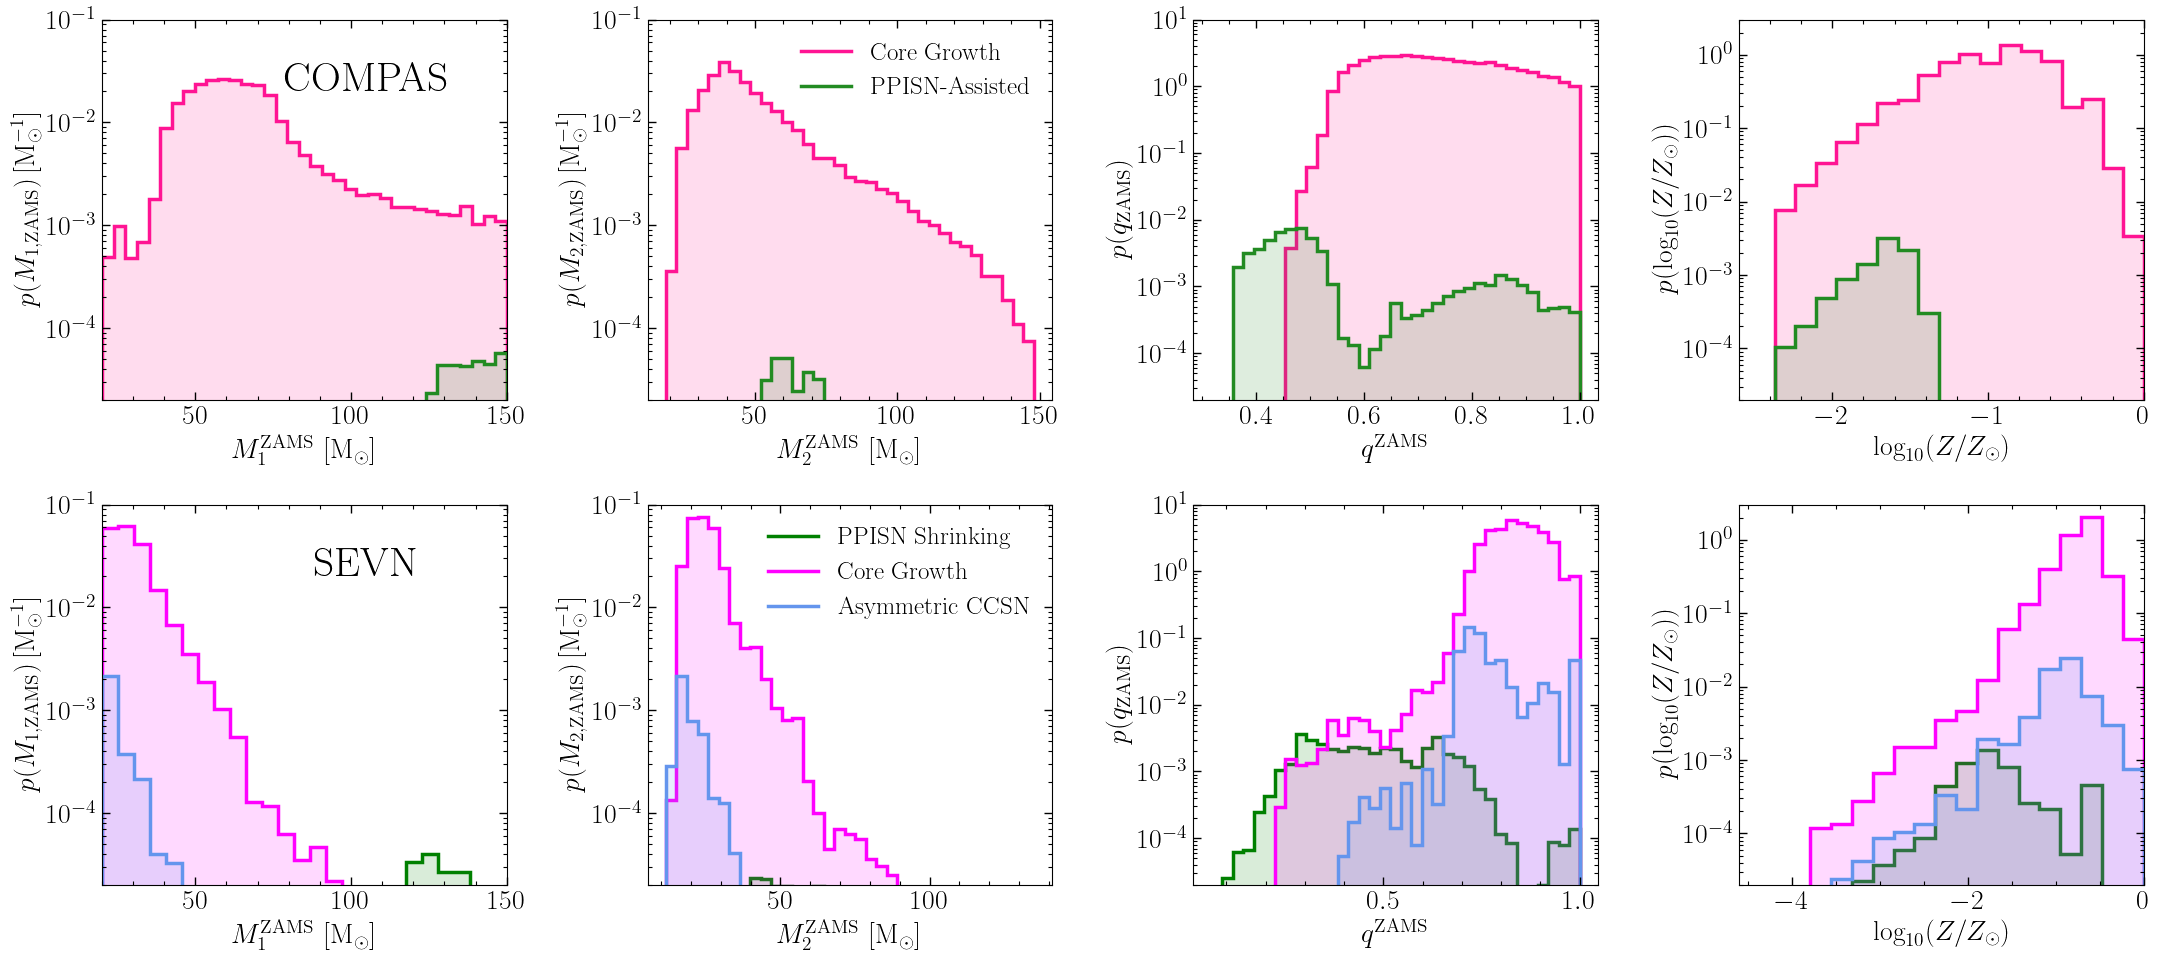

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10), sharey=False)

fill_row(axes[0], df_mrr_compas, "weight",  outcomes_compas, colors_compas, Z_edges_compas)
fill_row(axes[1], df_mrr_sevn,   "yield_w", outcomes_sevn,   colors_sevn,   Z_edges_sevn)

for row in axes:
    apply_ylims(row)
    apply_ylabels(row)

axes[0][0].text(105, 2e-2, "COMPAS", ha="center", fontsize=30)
axes[1][0].text(105, 2e-2, "SEVN",   ha="center", fontsize=30)

plt.tight_layout()
plt.savefig("../plots/final-channels-mrd-weighted-megaplot.pdf")
plt.show()

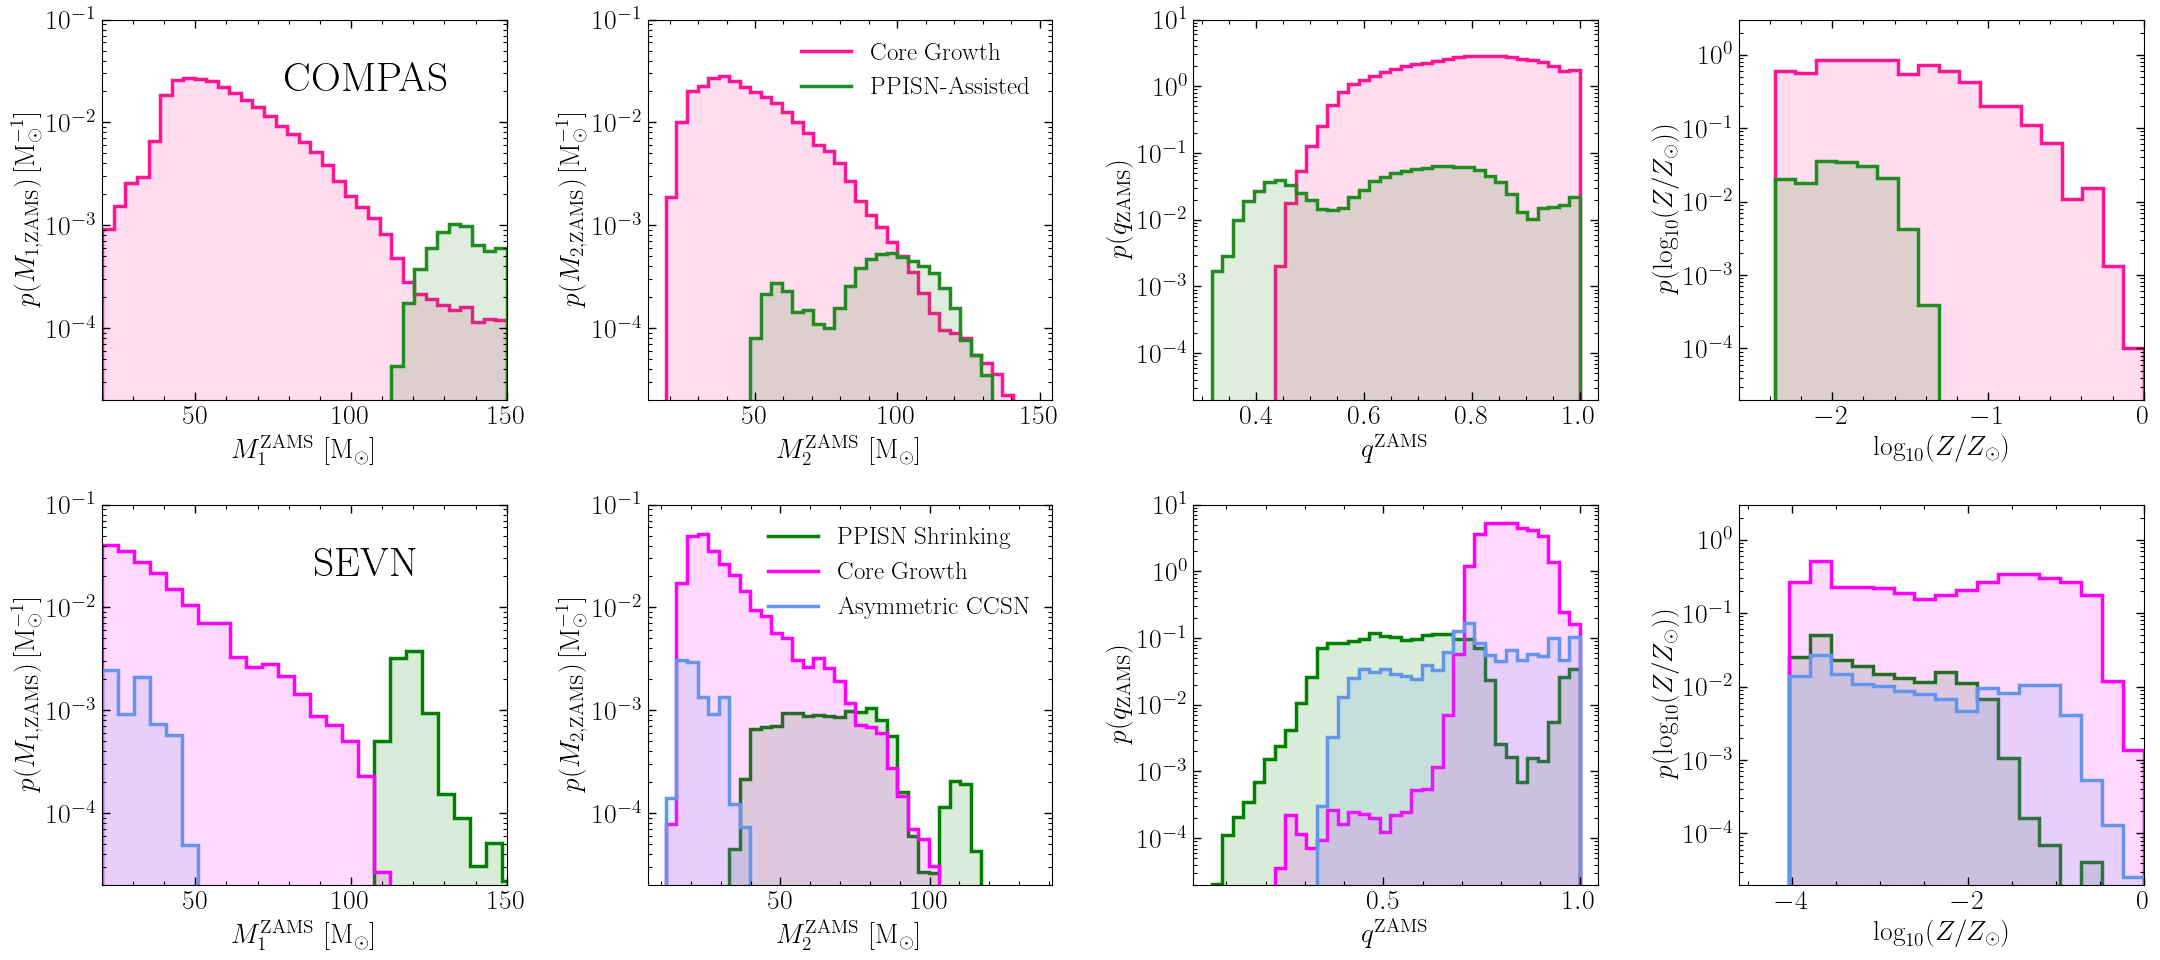

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10), sharey=False)

fill_row(axes[0], df_mrr_compas, "formation_weight",            outcomes_compas, colors_compas, Z_edges_compas)
fill_row(axes[1], df_mrr_sevn,   "number_per_solar_mass_values", outcomes_sevn,   colors_sevn,   Z_edges_sevn)

for row in axes:
    apply_ylims(row)
    apply_ylabels(row)

axes[0][0].text(105, 2e-2, "COMPAS", ha="center", fontsize=30)
axes[1][0].text(105, 2e-2, "SEVN",   ha="center", fontsize=30)

plt.tight_layout()
plt.savefig("../plots/final-channels-formation-weighted-megaplot.pdf")
plt.show()